In [45]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [46]:
df = pd.read_csv("advertising.csv")
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


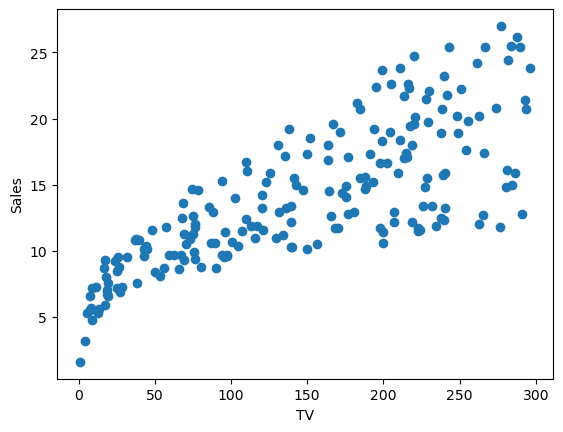

In [47]:
plt.scatter(df["TV"], df["sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

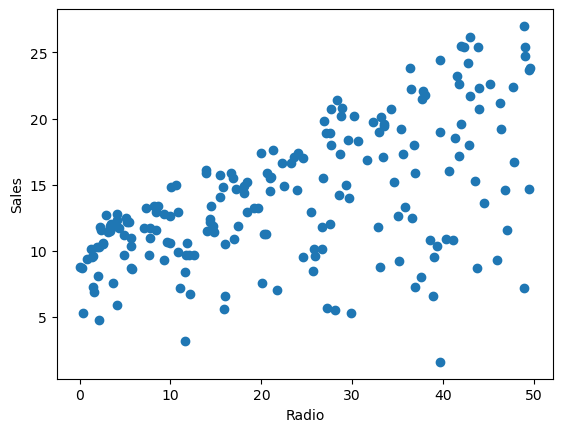

In [48]:
plt.scatter("radio","sales", data=df)
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.show()

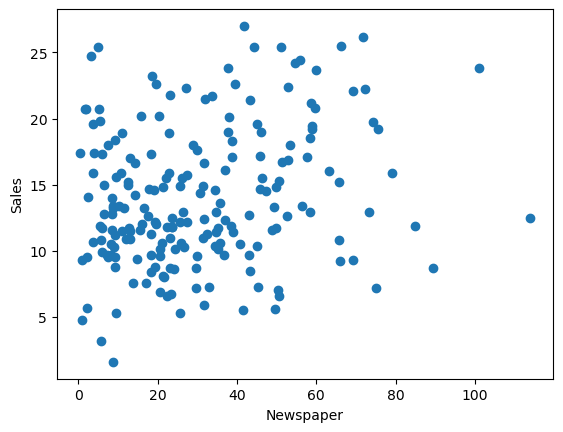

In [49]:
plt.scatter(df["newspaper"], df["sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.show()

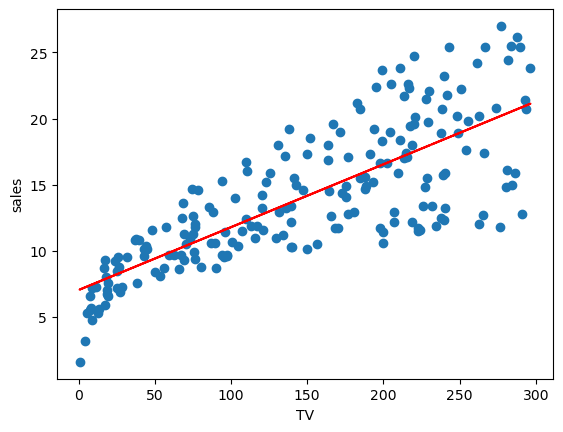

In [50]:
lr = LinearRegression()
x = df[["TV"]]
y = df["sales"]

lr.fit(x, y)
pred = lr.predict(x)

plt.scatter(df["TV"], df["sales"])       # actual data
plt.plot(df["TV"], pred, color="red")    # fitted line
plt.xlabel("TV")
plt.ylabel("sales")
plt.show()


In [51]:
beta0 = lr.intercept_          # ordenada al origen (β₀)
beta1 = lr.coef_[0]            # pendiente (β₁)

print(f"beta0 = {beta0:.4f}")
print(f"beta1 = {beta1:.4f}")
print(f"sales = {beta0:.4f} + {beta1:.4f} * TV")


beta0 = 7.0326
beta1 = 0.0475
sales = 7.0326 + 0.0475 * TV


In [52]:
import numpy as np

n = len(y)
residuos = y - lr.predict(x)

# varianza residual (n-2 porque estimamos 2 parámetros)
s2 = np.sum(residuos**2) / (n - 2)

tv = df["TV"].values
Sxx = np.sum((tv - tv.mean())**2)

se_b1 = np.sqrt(s2 / Sxx)
se_b0 = np.sqrt(s2 * (1/n + tv.mean()**2 / Sxx))

print(f"β0 = {lr.intercept_:.4f} ± {se_b0:.4f}")
print(f"β1 = {lr.coef_[0]:.4f} ± {se_b1:.4f}")


β0 = 7.0326 ± 0.4578
β1 = 0.0475 ± 0.0027


In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

pred = lr.predict(x)

residuos = y - pred                    # error individual de cada punto

mse  = mean_squared_error(y, pred)     # error cuadrático medio
rmse = np.sqrt(mse)                    # en las mismas unidades que 'sales'
mae  = mean_absolute_error(y, pred)    # error absoluto medio
r2   = r2_score(y, pred)               # qué % de la varianza explica el modelo

print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")


MSE  = 10.5127
RMSE = 3.2423
MAE  = 2.5498
R²   = 0.6119


In [87]:
x_bar = df["TV"].mean()
X_disp = np.sum((df["TV"] - x_bar)**2)
n = len(df)
p = 2
e = df["sales"] - lr.predict(df[["TV"]])
e = e**2
rss = np.sum(e)
sigma_2 = (rss/(n-p))
Se_b0 = sigma_2*(1/n + x_bar**2/X_disp)
Se_b0 = Se_b0**0.5
Se_b1 = sigma_2*(1/X_disp)
Se_b1 = Se_b1**0.5

print(rss)
print(x_bar)
print(sigma_2)
print(X_disp)
print(Se_b0)
print(Se_b1)



2102.5305831313512
147.0425
10.618841328946218
1466819.02875
0.4578429402734785
0.0026906071877968703


In [83]:
t_b0 = lr.intercept_ /(Se_b0)
t_b1 = lr.coef_[0] /(Se_b1)
print(t_b0)
print(t_b1)

15.360275174117547
17.66762560087555


In [93]:
from scipy import stats
p_bi0 = 2*(1 - stats.t.cdf(np.abs(t_b0), n-2))
p_bi1 = 2*(1 - stats.t.cdf(np.abs(t_b1), n-2))
print(p_bi0)
print(p_bi1)

0.0
0.0
